In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
np.random.seed(42)

n = 500

df = pd.DataFrame({
    "CGPA": np.round(np.random.uniform(5.5, 9.8, n), 2),
    "Attendance": np.random.randint(55, 101, n),
    "Aptitude_Score": np.random.randint(40, 101, n),
    "Coding_Score": np.random.randint(30, 101, n),
    "Communication_Score": np.random.randint(40, 101, n),
    "Internships": np.random.randint(0, 3, n),
    "Projects": np.random.randint(0, 5, n),
    "Backlogs": np.random.randint(0, 4, n)
})

df.head()

,CGPA,Attendance,Aptitude_Score,Coding_Score,Communication_Score,Internships,Projects,Backlogs
0,7.11,71,69,97,47,2,2,3
1,9.59,63,68,43,63,0,2,0
2,8.65,87,88,40,55,1,0,2
3,8.07,74,84,85,88,1,3,1
4,6.17,67,68,96,65,0,4,1


In [3]:
score = (
    df["CGPA"] * 10 +
    df["Attendance"] * 0.15 +
    df["Aptitude_Score"] * 0.25 +
    df["Coding_Score"] * 0.30 +
    df["Communication_Score"] * 0.15 +
    df["Internships"] * 8 +
    df["Projects"] * 5 -
    df["Backlogs"] * 12
)

df["Placement"] = np.where(score >= 125, "Placed", "Not Placed")

df.head()

,CGPA,Attendance,Aptitude_Score,Coding_Score,Communication_Score,Internships,Projects,Backlogs,Placement
0,7.11,71,69,97,47,2,2,3,Placed
1,9.59,63,68,43,63,0,2,0,Placed
2,8.65,87,88,40,55,1,0,2,Placed
3,8.07,74,84,85,88,1,3,1,Placed
4,6.17,67,68,96,65,0,4,1,Placed


In [4]:
print("Dataset Shape:", df.shape)

print("\nPlacement Distribution:")
print(df["Placement"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (500, 9)

Placement Distribution:
Placement
Placed        333
Not Placed    167
Name: count, dtype: int64

Missing Values:
CGPA                   0
Attendance             0
Aptitude_Score         0
Coding_Score           0
Communication_Score    0
Internships            0
Projects               0
Backlogs               0
Placement              0
dtype: int64


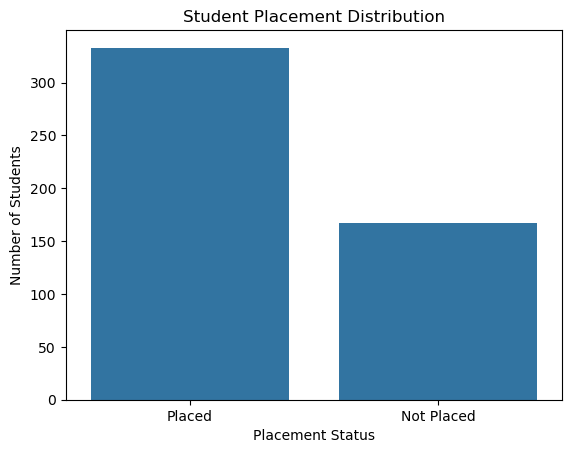

In [5]:
sns.countplot(x="Placement", data=df)

plt.title("Student Placement Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

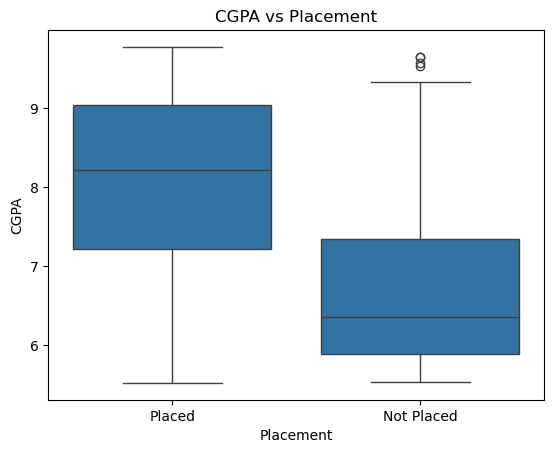

In [6]:
sns.boxplot(x="Placement", y="CGPA", data=df)

plt.title("CGPA vs Placement")
plt.show()

In [7]:
X = df.drop("Placement", axis=1)

y = df["Placement"].map({
    "Not Placed": 0,
    "Placed": 1
})

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 91.0 %


In [11]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Placed", "Placed"]
))

              precision    recall  f1-score   support

  Not Placed       0.96      0.76      0.85        33
      Placed       0.89      0.99      0.94        67

    accuracy                           0.91       100
   macro avg       0.93      0.87      0.89       100
weighted avg       0.91      0.91      0.91       100



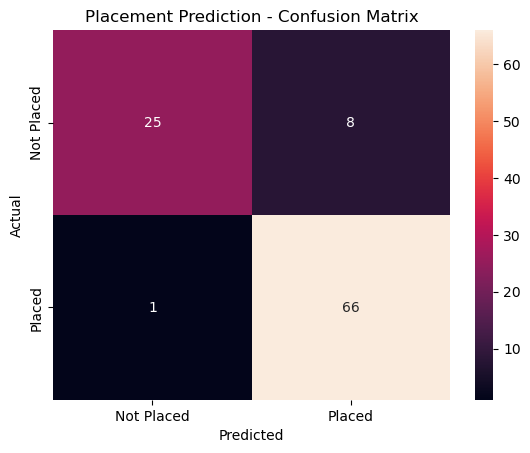

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Placement Prediction - Confusion Matrix")
plt.show()

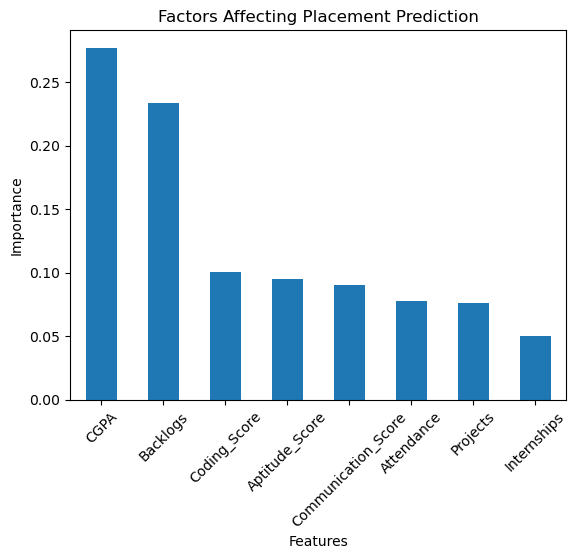

In [13]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar")

plt.title("Factors Affecting Placement Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [14]:
new_student = pd.DataFrame({
    "CGPA": [8.4],
    "Attendance": [88],
    "Aptitude_Score": [82],
    "Coding_Score": [78],
    "Communication_Score": [80],
    "Internships": [1],
    "Projects": [3],
    "Backlogs": [0]
})

prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

if prediction[0] == 1:
    print("Prediction: PLACED")
else:
    print("Prediction: NOT PLACED")

print("Placement Probability:", round(probability[0][1] * 100, 2), "%")

Prediction: PLACED
Placement Probability: 97.0 %
